# Simple SpecBridge Prediction Test

Load the pre-trained MSGYM model and predict SMILES from MS/MS spectra.

In [1]:
import sys
sys.path.insert(0, '/home/ids/silva-21/GraphConf/Models/SpecBridge')

import torch
import pickle
from pathlib import Path

# Setup
base_dir = Path('/home/ids/silva-21/GraphConf/Models/SpecBridge')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## Load Dataset and Candidates

In [2]:
from specbridge.data.massspecgym import MassSpecGymDataset

# Load test dataset
dataset = MassSpecGymDataset(
    mgf_path=str(base_dir / 'data/SpecBridge_MassSpecGym_dataset.mgf'),
    folds={'test'}
)

# Load candidates
with open(base_dir / 'data/SpecBridge_MSGYM_candidates.pkl', 'rb') as f:
    candidates_dict = pickle.load(f)

print(f"Dataset: {len(dataset)} test samples")
print(f"Candidates: {len(candidates_dict)} sets")

Dataset: 17556 test samples
Candidates: 32010 sets


## Load Pre-trained Model

In [3]:
from specbridge.adapters.dreams_adapter import load_dreams_encoder
from specbridge.models.mapper import DreamsToMolCondition
from specbridge.data.massspecgym import bin_peaks
from argparse import Namespace

# Load models (exactly like candidates.py line 178-192)
print("Loading models...")
dreams_encoder = load_dreams_encoder(str(base_dir / 'runs/DreaMS/ssl_model.ckpt'), d_in=2048, d_out=1024)

# Create args namespace (required by DreamsToMolCondition)
args = Namespace(n_blocks=8)

model = DreamsToMolCondition(
    dreams_encoder,
    d_out=2048,
    mapper_hidden=2048,
    gaussian=False,
    mol_space='chemberta',
    chemberta_model='Derify/ChemBERTa_augmented_pubchem_13m',
    args=args
).to(device).eval()

# Load checkpoint (exactly like candidates.py line 193-195)
checkpoint = torch.load(base_dir / 'runs/msgym/SpecBridge_MSGYM_checkpoint.pt', map_location='cpu')
model.load_state_dict(checkpoint.get("model", {}), strict=False)

for p in model.parameters():
    p.requires_grad = False

print(f"✓ Model loaded (checkpoint step {checkpoint.get('step', 'unknown')})")

Loading models...


/home/ids/silva-21/GraphConf/Models/SpecBridge/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using dreams encoder from checkpoint /home/ids/silva-21/GraphConf/Models/SpecBridge/runs/DreaMS/ssl_model.ckpt


Some weights of RobertaModel were not initialized from the model checkpoint at Derify/ChemBERTa_augmented_pubchem_13m and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Model loaded (checkpoint step 1200)


## Prediction Function

In [4]:
def predict_smiles(spectrum_sample, candidate_smiles_list, top_k=1):
    """
    Predict SMILES from MS/MS spectrum (exactly like candidates.py and predict_smiles.py).
    
    Args:
        spectrum_sample: dict with 'mz' and 'intensity' tensors
        candidate_smiles_list: list of candidate SMILES strings
        top_k: number of top predictions to return
    
    Returns:
        List of (smiles, score) tuples
    """
    with torch.no_grad():
        # Prepare spectrum (exactly like candidates.py line 435-438)
        mz, intensity = spectrum_sample['mz'].to(device), spectrum_sample['intensity'].to(device)
        spec_binned = bin_peaks(mz, intensity, num_bins=2048, max_mz=2000.0).unsqueeze(0)
        peaks = torch.stack([mz, intensity], dim=-1).unsqueeze(0)
        
        # Add dummy SMILES to meta (required by model forward, but not used for query)
        meta = {'peaks': peaks, 'smi_key': ['C']}
        
        # Forward pass (exactly like candidates.py line 444)
        z_s, z_m, z_hat, mu, lv = model(spec_binned, meta, None, inference=True)
        
        # Use mu as query (like candidates.py line 474)
        z_query = mu  # [1, 768] - in ChemBERTa space
        
        # Get candidate embeddings (exactly like predict_smiles.py line 86)
        cand_embs = model._chemberta_embed(candidate_smiles_list, device)  # [N, 768]
        
        # Compute similarities (exactly like candidates.py line 495-497)
        zq_norm = torch.nn.functional.normalize(z_query, dim=-1)  # [1, 768]
        Z_norm = torch.nn.functional.normalize(cand_embs, dim=-1)  # [N, 768]
        similarities = (zq_norm @ Z_norm.T).squeeze(0)  # [N]
        
        # Get top-k
        top_scores, top_indices = torch.topk(similarities, k=min(top_k, len(candidate_smiles_list)))
        
        results = [(candidate_smiles_list[idx], score.item()) 
                   for idx, score in zip(top_indices.cpu(), top_scores.cpu())]
        
    return results

In [5]:
# Get a test sample
sample = dataset[10]
true_smiles = sample['smiles']

# Get candidates for this sample
sample_id = sample['title']
candidates = candidates_dict.get(true_smiles, [])

print(f"Sample: {sample_id}")
print(f"True SMILES: {true_smiles}")
print(f"Number of candidates: {len(candidates)}")

Sample: idx_178
True SMILES: CC(C)[C@@H]1C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O1)CC2=CC=CC=C2)C)C(C)C)CC3=CC=CC=C3)C)C(C)C)CC4=CC=CC=C4)C
Number of candidates: 32


In [6]:
# Run prediction
predictions = predict_smiles(sample, candidates, top_k=5)

print("\nTop 5 Predictions:")
for i, (smiles, score) in enumerate(predictions, 1):
    is_correct = "✓" if smiles == true_smiles else "✗"
    print(f"{i}. {is_correct} {smiles[:60]} | score: {score:.4f}")


Top 5 Predictions:
1. ✓ CC(C)[C@@H]1C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H](C(=O)O[C@ | score: 0.8274
2. ✗ C[C@H](CCC(=O)ON1C(=O)CCC1=O)[C@H]1CC[C@H]2[C@@H]3CC[C@@H]4C | score: 0.8241
3. ✗ COC(=O)/C(C)=C\CC1(O)C(=O)C2CC(C(C)C)C13Oc1c(CC=C(C)C)c4c(c( | score: 0.8216
4. ✗ CC(=O)O[C@@H](C)/C=C\C(=O)N[C@@H]1C[C@H](C)[C@H](C/C=C(C)/C= | score: 0.7759
5. ✗ C.CC=CC[C@H](NC(=O)c1ccccc1)C(=O)OC.COC(=O)/C(=C/C=C(C)C)NC( | score: 0.7746


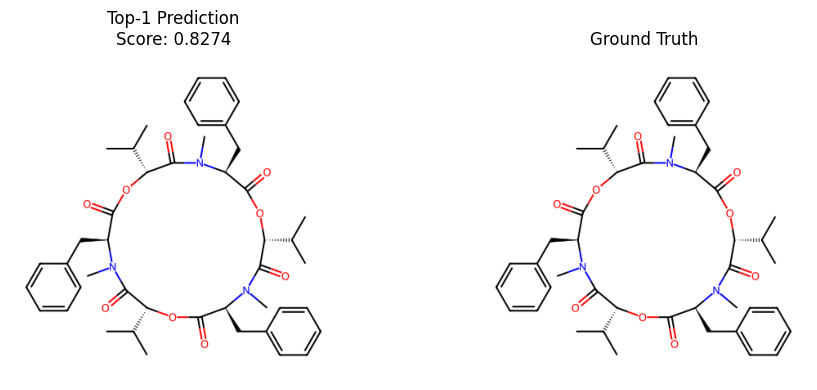

In [7]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display
import matplotlib.pyplot as plt

# Show top prediction vs true molecule
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Top prediction
top_smiles = predictions[0][0]
mol = Chem.MolFromSmiles(top_smiles)
if mol:
    img = Draw.MolToImage(mol, size=(400, 400))
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title(f"Top-1 Prediction\nScore: {predictions[0][1]:.4f}")

# True molecule
mol_true = Chem.MolFromSmiles(true_smiles)
if mol_true:
    img_true = Draw.MolToImage(mol_true, size=(400, 400))
    ax2.imshow(img_true)
    ax2.axis('off')
    ax2.set_title("Ground Truth")

plt.tight_layout()
plt.show()

## Convert SMILES to Graphs for FGW Distance

In [8]:
import sys
sys.path.insert(0, '/home/ids/silva-21/GraphConf')

from conformal.FGW import Graph, fgw_k
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def smiles_to_graph(smiles, use_onehot=True):
    from rdkit import Chem
    from rdkit.Chem import rdmolops
    import numpy as np

    mol = Chem.MolFromSmiles(smiles, sanitize=False)
    if mol is None:
        raise ValueError(f"Invalid SMILES: {smiles}")

    Chem.SanitizeMol(mol)

    if len(rdmolops.GetMolFrags(mol)) > 1:
        raise ValueError(f"Disconnected molecule: {smiles}")

    
    n_atoms = mol.GetNumAtoms()
    A = np.zeros((n_atoms, n_atoms), dtype=np.float32)

    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        A[i, j] = 1
        A[j, i] = 1

    atom_types = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]
    atom_to_idx = {a: i for i, a in enumerate(atom_types)}
    n_atom_types = len(atom_types) + 1

    F = []
    for atom in mol.GetAtoms():
        atomic_num = atom.GetAtomicNum()
        if use_onehot:
            onehot = np.zeros(n_atom_types, dtype=np.float32)
            onehot[atom_to_idx.get(atomic_num, -1)] = 1.0
            F.append(onehot)
        else:
            F.append([atomic_num])

    return Graph(A=A, F=np.array(F, dtype=np.float32))


In [9]:
# Convert prediction and ground truth to graphs
pred_smiles = predictions[0][0]  # Top-1 prediction
true_smiles = sample['smiles']

g_pred = smiles_to_graph(pred_smiles)
g_true = smiles_to_graph(true_smiles)

print(f"Predicted molecule graph: {g_pred.A.shape[0]} atoms")
print(f"Ground truth graph: {g_true.A.shape[0]} atoms")
print(f"Predicted Node features shape: {g_pred.F.shape}")
print(f"Ground Truth Node features shape: {g_true.F.shape}")

Predicted molecule graph: 57 atoms
Ground truth graph: 57 atoms
Predicted Node features shape: (57, 11)
Ground Truth Node features shape: (57, 11)


In [10]:
from scipy.sparse.csgraph import shortest_path
import ot
def fgw_k(
    g1: Graph,
    g2: Graph,
    k: int = 1,
    alpha: float = 0.5,
    loss_fun: str = "square_loss",
    sp: bool = False,
) -> float:
    """
    Compute FGW distance between two graphs using A^k.

    For k = 1, recovers standard FGW.
    """

    # Number of nodes
    n1, n2 = g1.A.shape[0], g2.A.shape[0]

    # Uniform node distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2

    # Feature distance matrix (Euclidean)
    C = ot.dist(g1.F, g2.F, metric="euclidean")
    A1_k = g1.A
    A2_k = g2.A

    if sp:
        # Compute shortest-path distance matrices
        A1_k = shortest_path(A1_k, directed=False, unweighted=True)
        A2_k = shortest_path(A2_k, directed=False, unweighted=True)
    

    fgw2 = ot.gromov.fused_gromov_wasserstein2(
        C,
        A1_k,
        A2_k,
        p,
        q,
        loss_fun=loss_fun,
        alpha=alpha,
        verbose=False,
    )
    return fgw2

In [11]:
def check_same_features(g1: Graph, g2: Graph) -> bool:
    """
    Check if two graphs have the same node features (F).
    
    Args:
        g1, g2: Graph objects
        
    Returns:
        True if features are identical, False otherwise
    """
    return np.array_equal(g1.F, g2.F)

# Test the function
same_features = check_same_features(g_pred, g_true)
print(f"Same features: {same_features}")
print(f"g_pred.F.shape: {g_pred.F.shape}")
print(f"g_true.F.shape: {g_true.F.shape}")

Same features: True
g_pred.F.shape: (57, 11)
g_true.F.shape: (57, 11)


In [12]:
# Compute FGW distance between predicted and ground truth graphs
fgw_dist = fgw_k(g_pred, g_true, k=1, alpha=0.4, loss_fun="square_loss", sp=True)

print(f"FGW distance: {fgw_dist:.6f}")
print(f"\nPrediction score: {predictions[0][1]:.4f}")
print(f"Correct prediction: {'Yes ✓' if pred_smiles == true_smiles else 'No ✗'}")

FGW distance: 0.000000

Prediction score: 0.8274
Correct prediction: Yes ✓


### Compute FGW distances for all top-k predictions

In [13]:
# Compute FGW distances for all top-5 predictions
print("Rank | Model Score | FGW Distance | SMILES")
print("-" * 80)

for i, (smiles, score) in enumerate(predictions, 1):
    try:
        g_cand = smiles_to_graph(smiles)
        fgw_dist = fgw_k(g_cand, g_cand, k=1, alpha=0.4, loss_fun="square_loss", sp=True)
        is_correct = "✓" if smiles == true_smiles else " "
        print(f"{i:4d} | {score:11.4f} | {fgw_dist:12.6f} | {is_correct} {smiles[:50]}")
    except Exception as e:
        print(f"{i:4d} | {score:11.4f} | {'ERROR':>12} | {smiles[:50]}")

Rank | Model Score | FGW Distance | SMILES
--------------------------------------------------------------------------------
   1 |      0.8274 |     0.000000 | ✓ CC(C)[C@@H]1C(=O)N([C@H](C(=O)O[C@@H](C(=O)N([C@H]
   2 |      0.8241 |    -0.000000 |   C[C@H](CCC(=O)ON1C(=O)CCC1=O)[C@H]1CC[C@H]2[C@@H]3
   3 |      0.8216 |     0.000000 |   COC(=O)/C(C)=C\CC1(O)C(=O)C2CC(C(C)C)C13Oc1c(CC=C(
   4 |      0.7759 |     0.000000 |   CC(=O)O[C@@H](C)/C=C\C(=O)N[C@@H]1C[C@H](C)[C@H](C
   5 |      0.7746 |        ERROR | C.CC=CC[C@H](NC(=O)c1ccccc1)C(=O)OC.COC(=O)/C(=C/C


### Visualize Graph Structures

/tmp/ipykernel_2174241/2034890890.py:134: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


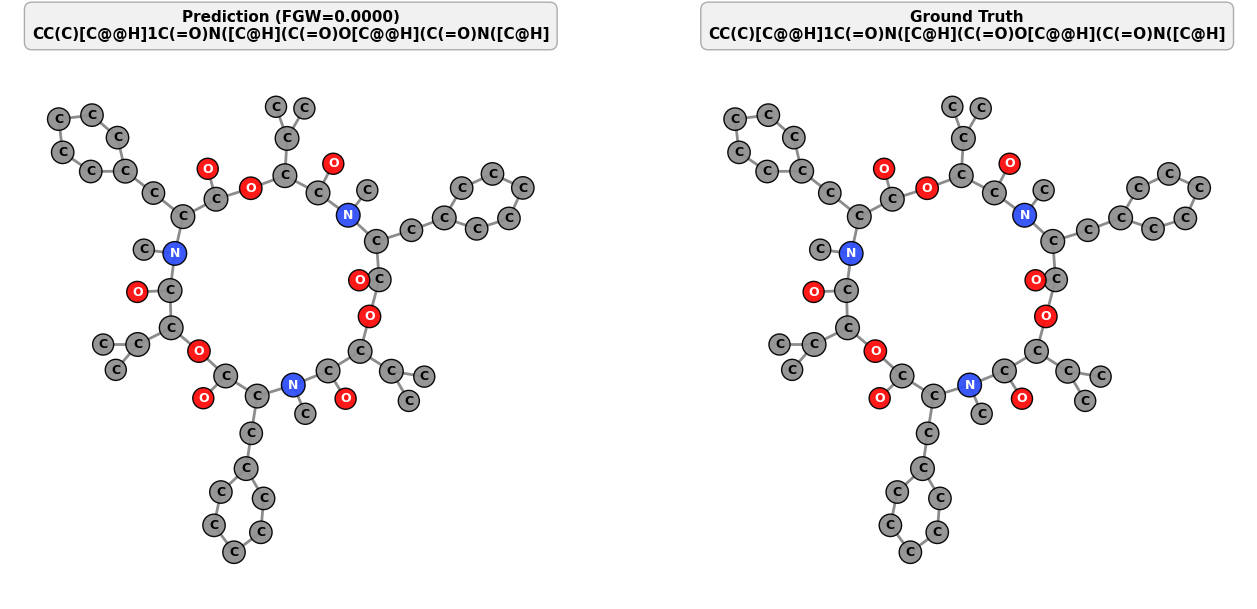


Predicted: 57 atoms, 60 bonds
True:      57 atoms, 60 bonds


In [14]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

def plot_molecular_graph(graph, smiles, title, ax):
    """Plot beautiful molecular graph with atom-specific colors and styling."""
    # Create networkx graph
    G = nx.from_numpy_array(graph.A)
    
    # CPK coloring scheme (standard atom colors in chemistry)
    atom_colors = {
        1: '#FFFFFF',   # H - White
        6: '#909090',   # C - Gray
        7: '#3050F8',   # N - Blue
        8: '#FF0D0D',   # O - Red
        9: '#90E050',   # F - Green
        15: '#FF8000',  # P - Orange
        16: '#FFFF30',  # S - Yellow
        17: '#1FF01F',  # Cl - Green
        35: '#A62929',  # Br - Dark red
        53: '#940094',  # I - Purple
    }
    
    atomic_symbols = {1: 'H', 6: 'C', 7: 'N', 8: 'O', 9: 'F', 15: 'P', 16: 'S', 17: 'Cl', 35: 'Br', 53: 'I'}
    atom_types = [1, 6, 7, 8, 9, 15, 16, 17, 35, 53]  # From smiles_to_graph
    
    # Prepare node attributes
    node_colors = []
    labels = {}
    node_sizes = []
    
    for i in range(graph.F.shape[0]):
        # Decode atomic number from one-hot encoding
        if graph.F.shape[1] > 1:  # One-hot encoded
            atom_idx = np.argmax(graph.F[i])
            if atom_idx < len(atom_types):
                atomic_num = atom_types[atom_idx]
            else:
                atomic_num = 0  # Unknown
        else:  # Raw atomic number
            atomic_num = int(graph.F[i, 0])
        
        # Get degree from adjacency matrix
        degree = int(graph.A[i].sum())
        
        # Color based on atom type
        node_colors.append(atom_colors.get(atomic_num, '#FF1493'))  # Hot pink for unknown
        
        # Label
        labels[i] = atomic_symbols.get(atomic_num, str(atomic_num))
        
        # Size based on degree
        base_size = 200
        size = base_size + degree * 30
        node_sizes.append(size)
    
    # Better layout - try kamada_kawai for more uniform spacing
    try:
        pos = nx.kamada_kawai_layout(G)
    except:
        pos = nx.spring_layout(G, seed=42, k=2, iterations=100)
    
    # Draw edges with varying thickness based on connectivity
    edge_widths = []
    for edge in G.edges():
        width = 2.0
        edge_widths.append(width)
    
    nx.draw_networkx_edges(
        G, pos, ax=ax, 
        alpha=0.6, 
        width=edge_widths,
        edge_color='#404040',
        style='solid'
    )
    
    # Draw nodes with colors
    nx.draw_networkx_nodes(
        G, pos, ax=ax, 
        node_color=node_colors,
        node_size=node_sizes,
        alpha=0.95,
        edgecolors='black',
        linewidths=1.0
    )
    
    # Draw labels with contrasting colors
    for node, (x, y) in pos.items():
        # Decode atomic number for this node
        if graph.F.shape[1] > 1:  # One-hot encoded
            atom_idx = np.argmax(graph.F[node])
            if atom_idx < len(atom_types):
                atomic_num = atom_types[atom_idx]
            else:
                atomic_num = 0
        else:
            atomic_num = int(graph.F[node, 0])
        
        label = labels[node]
        
        # Use white text for dark atoms, black for light atoms
        if atomic_num in [7, 8, 35, 53]:  # N, O, Br, I (darker colors)
            text_color = 'white'
        else:
            text_color = 'black'
        
        ax.text(x, y, label, 
                fontsize=9, 
                fontweight='bold',
                ha='center', 
                va='center',
                color=text_color,
                family='sans-serif')
    
    # Beautiful title with box
    ax.set_title(f"{title}\n{smiles[:50]}", 
                 fontsize=11, 
                 fontweight='bold',
                 pad=15,
                 bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.3))
    ax.axis('off')
    ax.set_aspect('equal')

# Plot both graphs with white background
fig = plt.figure(figsize=(16, 7), facecolor='white')
gs = fig.add_gridspec(1, 2, hspace=0.3, wspace=0.2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

plot_molecular_graph(g_pred, pred_smiles, f"Prediction (FGW={fgw_dist:.4f})", ax1)
plot_molecular_graph(g_true, true_smiles, "Ground Truth", ax2)

plt.tight_layout()
plt.show()

print(f"\nPredicted: {g_pred.A.shape[0]} atoms, {int(g_pred.A.sum()//2)} bonds")
print(f"True:      {g_true.A.shape[0]} atoms, {int(g_true.A.sum()//2)} bonds")

# Conformal Prediction with FGW

We'll implement conformal prediction using FGW distances:
1. Split test data into calibration and test sets
2. Compute FGW scores on calibration (top-1 prediction vs ground truth)
3. Calculate empirical quantile threshold (1-α)
4. Apply conformal prediction on test set by filtering candidates based on FGW threshold
5. Evaluate coverage (% ground truth in conformal set) and set sizes

In [15]:
import numpy as np
import random
from typing import List, Tuple, Dict
from tqdm import tqdm

# Set random seeds for reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# Configuration
CALIBRATION_PERCENTAGE = 0.6  # 60% for calibration, 40% for test
ALPHA = 0.1  # Significance level (90% coverage target)
FGW_K = 1  # FGW parameter
FGW_ALPHA = 0.4  # FGW alpha parameter
USE_SP = True  # Use shortest path for FGW

In [16]:
# Split test dataset into calibration and test sets
def split_dataset(dataset, candidates_dict, calib_percentage=0.2):
    """
    Randomly split dataset into calibration and test sets.
    
    Args:
        dataset: MassSpecGymDataset object
        candidates_dict: Dictionary of candidate sets (keyed by SMILES)
        calib_percentage: Fraction of data for calibration
        
    Returns:
        calib_indices, test_indices: Lists of indices for each split
    """
    # Get all valid indices (samples with candidates)
    all_indices = []
    for idx in range(len(dataset)):
        sample = dataset[idx]
        true_smiles = sample['smiles']
        if true_smiles in candidates_dict:
            all_indices.append(idx)
    
    # Shuffle and split
    random.shuffle(all_indices)
    n_calib = int(len(all_indices) * calib_percentage)
    
    calib_indices = all_indices[:n_calib]
    test_indices = all_indices[n_calib:]
    
    return calib_indices, test_indices

# Perform the split
calib_indices, test_indices = split_dataset(dataset, candidates_dict, CALIBRATION_PERCENTAGE)

print(f"\nDataset split:")
print(f"  Calibration set: {len(calib_indices)} samples")
print(f"  Test set: {len(test_indices)} samples")
print(f"  Total: {len(calib_indices) + len(test_indices)} samples")


Dataset split:
  Calibration set: 10533 samples
  Test set: 7023 samples
  Total: 17556 samples


## Step 1: Compute Calibration Scores

For each calibration sample, we:
1. Get top-1 prediction from the model
2. Compute FGW distance between prediction and ground truth
3. Store this as the calibration score

In [17]:
def compute_calibration_scores(dataset, candidates_dict, indices):
    """
    Compute FGW calibration scores for given dataset indices.
    
    For each sample:
    - Get top-1 prediction from model
    - Compute FGW(pred, ground_truth)
    - Return as calibration score
    
    Args:
        dataset: MassSpecGymDataset
        candidates_dict: Dictionary of candidate sets (keyed by SMILES)
        indices: List of dataset indices to process
        
    Returns:
        calibration_scores: List of FGW distances
        valid_indices: List of indices that were successfully processed
    """
    calibration_scores = []
    valid_indices = []
    
    print(f"Computing calibration scores for {len(indices)} samples...")
    
    for idx in tqdm(indices):
        try:
            # Get sample and candidates
            sample = dataset[idx]
            true_smiles = sample['smiles']
            candidates = candidates_dict[true_smiles]
            
            # Get top-1 prediction
            predictions = predict_smiles(sample, candidates, top_k=1)
            pred_smiles = predictions[0][0]
            
            # Convert to graphs
            g_pred = smiles_to_graph(pred_smiles)
            g_true = smiles_to_graph(true_smiles)
            
            # Compute FGW distance
            fgw_score = fgw_k(g_pred, g_true, k=FGW_K, alpha=FGW_ALPHA, 
                            loss_fun="square_loss", sp=USE_SP)
            
            calibration_scores.append(fgw_score)
            valid_indices.append(idx)
            
        except Exception as e:
            print(f"\nWarning: Failed to process sample {idx}: {str(e)}")
            continue
    
    return np.array(calibration_scores), valid_indices

# Compute calibration scores
calibration_scores, valid_calib_indices = compute_calibration_scores(
    dataset, candidates_dict, calib_indices
)

print(f"\nCalibration scores computed:")
print(f"  Valid samples: {len(calibration_scores)}")
print(f"  Mean FGW: {np.mean(calibration_scores):.6f}")
print(f"  Median FGW: {np.median(calibration_scores):.6f}")
print(f"  Std FGW: {np.std(calibration_scores):.6f}")
print(f"  Min FGW: {np.min(calibration_scores):.6f}")
print(f"  Max FGW: {np.max(calibration_scores):.6f}")

Computing calibration scores for 10533 samples...


  0%|          | 8/10533 [00:01<36:41,  4.78it/s]

  0%|          | 18/10533 [00:03<25:07,  6.98it/s]

  0%|          | 30/10533 [00:05<33:31,  5.22it/s]

  1%|          | 131/10533 [00:25<35:42,  4.85it/s]

...

 99%|█████████▉| 10436/10533 [36:11<00:21,  4.43it/s]

100%|█████████▉| 10505/10533 [36:25<00:05,  4.71it/s]

100%|█████████▉| 10517/10533 [36:27<00:03,  4.30it/s]

100%|██████████| 10533/10533 [36:31<00:00,  4.81it/s]



Calibration scores computed:
  Valid samples: 10395
  Mean FGW: 0.648892
  Median FGW: 0.000000
  Std FGW: 3.596373
  Min FGW: -0.000000
  Max FGW: 69.591835


## Step 2: Calculate Empirical Quantile Threshold

We compute the (1-α) quantile of calibration scores. This threshold will be used to filter candidates in the test set.

In [18]:
# Calculate the (1-alpha) quantile threshold
# For conformal prediction, we use the ceiling quantile
n_calib = len(calibration_scores)
quantile_level = np.ceil((n_calib + 1) * (1 - ALPHA)) / n_calib
threshold = np.quantile(calibration_scores, quantile_level, method='higher')

print(f"Conformal threshold calculation:")
print(f"  Quantile level: {quantile_level:.4f}")
print(f"  Threshold: {threshold:.6f}")
print(f"  Number of calibration scores ≤ threshold: {np.sum(calibration_scores <= threshold)}")
print(f"  Percentage: {100 * np.sum(calibration_scores <= threshold) / n_calib:.2f}%")

Conformal threshold calculation:
  Quantile level: 0.9001
  Threshold: 1.584007
  Number of calibration scores ≤ threshold: 9358
  Percentage: 90.02%


## Step 3: Apply Conformal Prediction on Test Set

For each test sample:
1. Get top-1 prediction from model
2. Compute FGW distance between prediction and each candidate
3. Keep candidates where FGW(pred, candidate) ≤ threshold
4. This forms the conformal prediction set

In [24]:
def apply_conformal_prediction(dataset, candidates_dict, indices, threshold):
    """
    Apply conformal prediction on test set using FGW threshold.
    
    For each test sample:
    1. Get top-1 prediction
    2. Compute FGW(pred, candidate) for each candidate
    3. Keep candidates where FGW ≤ threshold
    
    Args:
        dataset: MassSpecGymDataset
        candidates_dict: Dictionary of candidate sets (keyed by SMILES)
        indices: List of test indices
        threshold: FGW threshold from calibration
        
    Returns:
        results: List of dicts with test results
    """
    results = []
    
    print(f"Applying conformal prediction on {len(indices)} test samples...")
    
    for idx in tqdm(indices):
        try:
            # Get sample and candidates
            sample = dataset[idx]
            true_smiles = sample['smiles']
            candidates = candidates_dict[true_smiles]
            
            # Get top-1 prediction
            predictions = predict_smiles(sample, candidates, top_k=1)
            pred_smiles = predictions[0][0]
            
            # Convert prediction to graph
            g_pred = smiles_to_graph(pred_smiles)
            g_true = smiles_to_graph(true_smiles)
            
            # Compute FGW distance for each candidate
            conformal_set = []
            candidate_fgw_scores = []
            
            for cand_smiles in candidates:
                try:
                    g_cand = smiles_to_graph(cand_smiles)
                    fgw_score = fgw_k(g_pred, g_cand, k=FGW_K, alpha=FGW_ALPHA,
                                    loss_fun="square_loss", sp=USE_SP)
                    candidate_fgw_scores.append(fgw_score)
                    
                    # Keep candidate if FGW ≤ threshold
                    if fgw_score <= threshold:
                        conformal_set.append(cand_smiles)
                except Exception as e:
                    # If candidate fails, skip it
                    continue
            
            # Check if ground truth is in conformal set
            gt_in_conformal = true_smiles in conformal_set
            gt_in_candidates = true_smiles in candidates
            
            # Store results
            results.append({
                'idx': idx,
                'sample_id': sample.get('title', f'sample_{idx}'),
                'true_smiles': true_smiles,
                'pred_smiles': pred_smiles,
                'candidate_set_size': len(candidates),
                'conformal_set_size': len(conformal_set),
                'conformal_set': conformal_set,
                'gt_in_candidates': gt_in_candidates,
                'gt_in_conformal': gt_in_conformal,
                'candidate_fgw_scores': candidate_fgw_scores,
                'pred_correct': pred_smiles == true_smiles
            })
            
        except Exception as e:
            print(f"\nWarning: Failed to process test sample {idx}: {str(e)}")
            continue
    
    return results

# Apply conformal prediction on test set
test_results = apply_conformal_prediction(dataset, candidates_dict, test_indices[:1000], threshold)

print(f"\nTest results:")
print(f"  Valid test samples: {len(test_results)}")

Applying conformal prediction on 1000 test samples...


  0%|          | 0/1000 [00:00<?, ?it/s]

 14%|█▍        | 145/1000 [03:23<11:25,  1.25it/s]

 19%|█▉        | 188/1000 [04:22<14:41,  1.08s/it]

 35%|███▌      | 353/1000 [08:30<12:55,  1.20s/it]

...

 63%|██████▎   | 632/1000 [14:59<11:04,  1.81s/it]

 70%|██████▉   | 696/1000 [16:26<04:51,  1.04it/s]

 78%|███████▊  | 777/1000 [18:28<04:32,  1.22s/it]

100%|██████████| 1000/1000 [23:50<00:00,  1.43s/it]


Test results:
  Valid test samples: 992


## Step 4: Evaluate Coverage and Set Sizes

Compute key metrics:
- **Coverage**: Percentage of test samples where ground truth is in the conformal set
- **Average candidate set size**: Mean size before conformal filtering
- **Average conformal set size**: Mean size after conformal filtering
- **Size reduction**: Percentage reduction in set size

In [44]:
# Calculate metrics
n_test = len(test_results)

# Coverage: % of times GT is in conformal set
coverage = np.mean([r['gt_in_conformal'] for r in test_results])

# Set sizes (only for cases where GT is in conformal set)
results_with_gt = [r for r in test_results if r['gt_in_conformal']]
avg_candidate_size = np.mean([r['candidate_set_size'] for r in results_with_gt])
avg_conformal_size = np.mean([r['conformal_set_size'] for r in results_with_gt])
median_candidate_size = np.median([r['candidate_set_size'] for r in results_with_gt])
median_conformal_size = np.median([r['conformal_set_size'] for r in results_with_gt])

# Size reduction
size_reduction = 100 * (1 - avg_conformal_size / avg_candidate_size)

# Top-1 accuracy
top1_accuracy = np.mean([r['pred_correct'] for r in test_results])

# Ground truth in original candidates
gt_in_candidates_rate = np.mean([r['gt_in_candidates'] for r in test_results])

print("="*80)
print("CONFORMAL PREDICTION RESULTS")
print(f"\nDataset Statistics:")
print(f"  Calibration samples: {len(calibration_scores)}")
print(f"  Test samples: {n_test}")
print(f"  Significance level (α): {ALPHA}")
print(f"  Target coverage: {(1-ALPHA)*100:.1f}%")

print(f"\nThreshold:")
print(f"  FGW threshold: {threshold:.6f}")

print(f"\nModel Performance:")
print(f"  Top-1 accuracy: {top1_accuracy*100:.2f}%")
print(f"  GT in candidates: {gt_in_candidates_rate*100:.2f}%")

print(f"\nConformal Prediction Performance:")
print(f"  Coverage: {coverage*100:.2f}% (target: {(1-ALPHA)*100:.0f}%)")

print(f"\nSet Sizes (when GT in conformal set):")
print(f"  Avg candidate set size: {avg_candidate_size:.2f}")
print(f"  Avg conformal set size: {avg_conformal_size:.2f}")
print(f"  Size reduction: {size_reduction:.2f}%")
print(f"  Median candidate set size: {median_candidate_size:.1f}")
print(f"  Median conformal set size: {median_conformal_size:.1f}")

print("="*80)

CONFORMAL PREDICTION RESULTS

Dataset Statistics:
  Calibration samples: 10395
  Test samples: 992
  Significance level (α): 0.1
  Target coverage: 90.0%

Threshold:
  FGW threshold: 1.584007

Model Performance:
  Top-1 accuracy: 82.06%
  GT in candidates: 100.00%

Conformal Prediction Performance:
  Coverage: 89.62% (target: 90%)

Set Sizes (when GT in conformal set):
  Avg candidate set size: 165.55
  Avg conformal set size: 88.14
  Size reduction: 46.76%
  Median candidate set size: 229.0
  Median conformal set size: 70.0


## Visualize Results

✓ Saved figure to: conformal_prediction_results.pdf


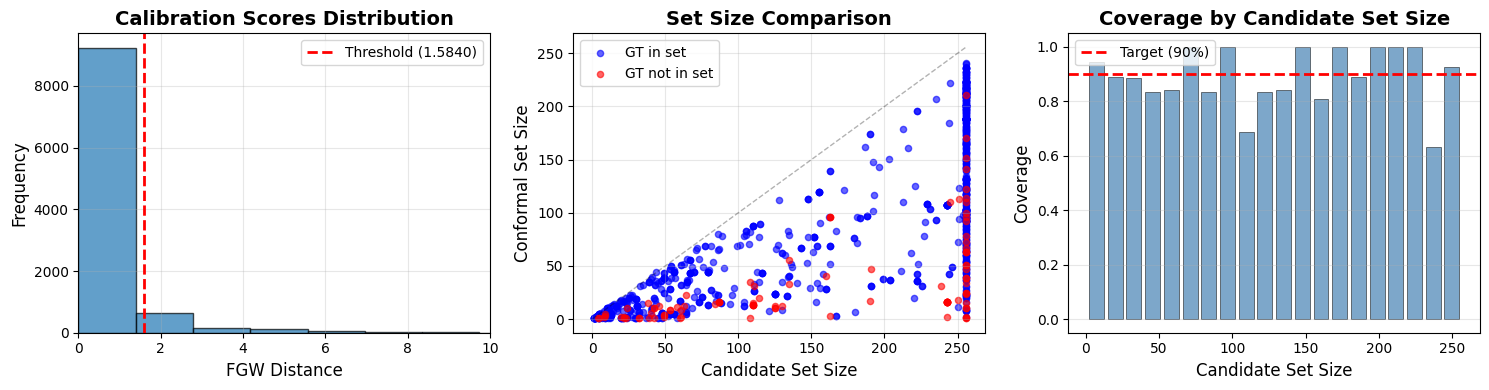

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Calibration scores distribution
axes[0].hist(calibration_scores, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')
axes[0].set_xlabel('FGW Distance', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Calibration Scores Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 10])  # Clip x-axis to show 0-10 range
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Set sizes comparison (color-coded by coverage)
candidate_sizes = [r['candidate_set_size'] for r in test_results]
conformal_sizes = [r['conformal_set_size'] for r in test_results]
gt_in_conformal = [r['gt_in_conformal'] for r in test_results]

# Separate points by coverage
candidate_sizes_correct = [candidate_sizes[i] for i in range(len(test_results)) if gt_in_conformal[i]]
conformal_sizes_correct = [conformal_sizes[i] for i in range(len(test_results)) if gt_in_conformal[i]]
candidate_sizes_incorrect = [candidate_sizes[i] for i in range(len(test_results)) if not gt_in_conformal[i]]
conformal_sizes_incorrect = [conformal_sizes[i] for i in range(len(test_results)) if not gt_in_conformal[i]]

# Plot correct (blue) and incorrect (red)
axes[1].scatter(candidate_sizes_correct, conformal_sizes_correct, alpha=0.6, s=20, c='blue', label='GT in set')
axes[1].scatter(candidate_sizes_incorrect, conformal_sizes_incorrect, alpha=0.6, s=20, c='red', label='GT not in set')
max_size = max(max(candidate_sizes), max(conformal_sizes))
axes[1].plot([0, max_size], [0, max_size], 'k--', alpha=0.3, linewidth=1)
axes[1].set_xlabel('Candidate Set Size', fontsize=12)
axes[1].set_ylabel('Conformal Set Size', fontsize=12)
axes[1].set_title('Set Size Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Plot 3: Coverage by candidate set size (histogram with confidence intervals)
from collections import defaultdict

size_to_coverage = defaultdict(list)
for r in test_results:
    size_to_coverage[r['candidate_set_size']].append(r['gt_in_conformal'])

# Create bins for candidate set sizes
all_sizes = [r['candidate_set_size'] for r in test_results]
min_size, max_size = min(all_sizes), max(all_sizes)

# Use reasonable number of bins
n_bins = min(20, len(set(all_sizes)))
bins = np.linspace(min_size, max_size, n_bins + 1)

# Compute coverage for each bin
bin_centers = []
bin_coverages = []
bin_counts = []

for i in range(len(bins) - 1):
    bin_start, bin_end = bins[i], bins[i + 1]
    
    # Get all samples in this bin
    samples_in_bin = [r['gt_in_conformal'] for r in test_results 
                     if bin_start <= r['candidate_set_size'] < bin_end or 
                     (i == len(bins) - 2 and r['candidate_set_size'] == bin_end)]
    
    if len(samples_in_bin) > 0:
        # Calculate coverage
        coverage_mean = np.mean(samples_in_bin)
        n = len(samples_in_bin)
        
        bin_centers.append((bin_start + bin_end) / 2)
        bin_coverages.append(coverage_mean)
        bin_counts.append(n)

# Plot bars
bin_width = bins[1] - bins[0]
bars = axes[2].bar(bin_centers, bin_coverages, width=bin_width * 0.8, 
                   alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)

# Add target line
axes[2].axhline(1-ALPHA, color='red', linestyle='--', linewidth=2, label=f'Target ({(1-ALPHA)*100:.0f}%)')



axes[2].set_xlabel('Candidate Set Size', fontsize=12)
axes[2].set_ylabel('Coverage', fontsize=12)
axes[2].set_title('Coverage by Candidate Set Size', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3, axis='y')
axes[2].set_ylim([-0.05, 1.05])
axes[2].set_xlim([min_size - bin_width, max_size + bin_width])

plt.tight_layout()

# Save as PDF
plt.savefig('conformal_prediction_results.pdf', format='pdf', bbox_inches='tight', dpi=300)
print("✓ Saved figure to: conformal_prediction_results.pdf")

plt.show()


## Detailed Analysis: Sample Examples

SMALL CONFORMAL SET EXAMPLE

Sample ID: idx_58889
Original Candidate Set Size: 13
Conformal Set Size: 4
Size Reduction: 69.2%

Ground Truth SMILES: CC1C(NC(=O)C(NC(=O)C(C(NC(=O)C(NC(=O)C(NC(=O)C(=C)N(C(=O)CCC(NC1=O)C(=O)O)C)C)CC(C)C)C(=O)O)C)CC2=CC=CC=C2)/C=C/C(=C/C(C)C(CC3=CC=CC=C3)OC)/C
Top-1 Prediction: CC1C(NC(=O)C(NC(=O)C(C(NC(=O)C(NC(=O)C(NC(=O)C(=C)N(C(=O)CCC(NC1=O)C(=O)O)C)C)CC(C)C)C(=O)O)C)CC2=CC=CC=C2)/C=C/C(=C/C(C)C(CC3=CC=CC=C3)OC)/C
Prediction Correct: Yes ✓

Conformal Set (4 molecules):
  1. CC1C(NC(=O)C(NC(=O)C(C(NC(=O)C(NC(=O)C(NC(=O)C(=C)N(C(=O)CCC... ✓ GROUND TRUTH
  2. C=C1C(=O)N[C@H](C)C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](C(=O)O... 
  3. C=C1C(=O)N[C@H](C)C(=O)N[C@@H](Cc2ccccc2)C(=O)N[C@@H](C(=O)O... 
  4. C=C1C(=O)NC(C)C(=O)NC(Cc2ccccc2)C(=O)NC(C(=O)O)C(C)C(=O)NC(C... 

✓ Saved figure to: conformal_set_example_idx_58889.pdf


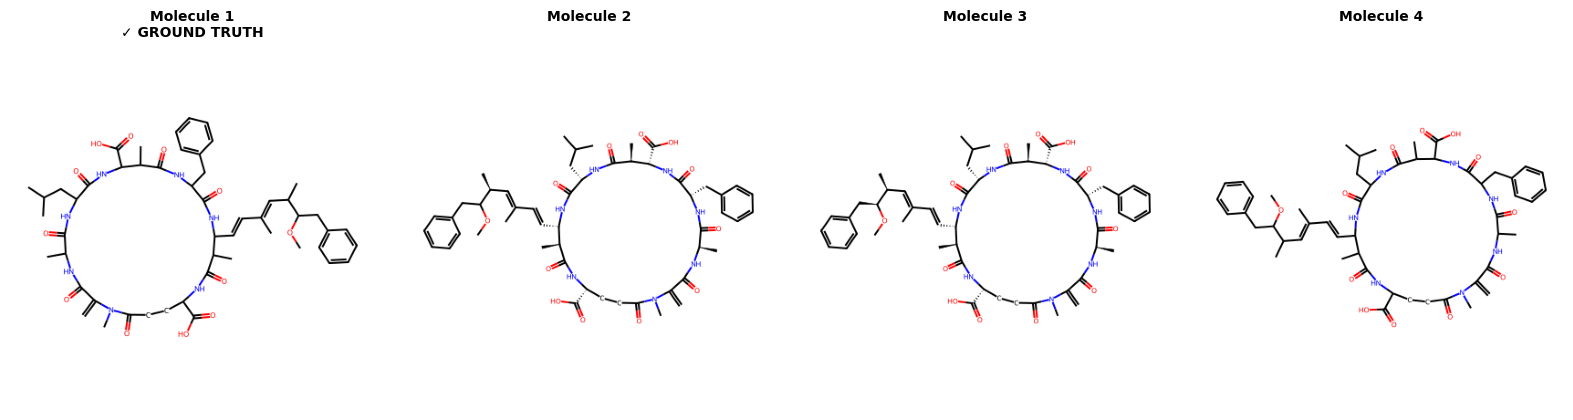

In [57]:
# Find a small conformal set (size 4) that contains the ground truth, with large original candidate set
small_conformal_examples = [r for r in test_results if r['conformal_set_size'] == 4 and r['gt_in_conformal'] and r['candidate_set_size'] > 10]

if small_conformal_examples:
    example = small_conformal_examples[0]
    
    print("="*80)
    print("SMALL CONFORMAL SET EXAMPLE")
    print("="*80)
    print(f"\nSample ID: {example['sample_id']}")
    print(f"Original Candidate Set Size: {example['candidate_set_size']}")
    print(f"Conformal Set Size: {example['conformal_set_size']}")
    print(f"Size Reduction: {100*(1 - example['conformal_set_size']/example['candidate_set_size']):.1f}%")
    print(f"\nGround Truth SMILES: {example['true_smiles']}")
    print(f"Top-1 Prediction: {example['pred_smiles']}")
    print(f"Prediction Correct: {'Yes ✓' if example['pred_correct'] else 'No ✗'}")
    
    # Visualize conformal set and ground truth
    from rdkit import Chem
    from rdkit.Chem import Draw
    import matplotlib.pyplot as plt
    
    conformal_smiles = example['conformal_set']
    true_smiles = example['true_smiles']
    
    # Create figure with 2 rows: top row for conformal set (4 molecules), bottom row for ground truth
    fig = plt.figure(figsize=(16, 8))
    
    # Plot conformal set molecules
    print(f"\nConformal Set ({len(conformal_smiles)} molecules):")
    for i, smiles in enumerate(conformal_smiles):
        ax = fig.add_subplot(2, 4, i + 1)
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax.imshow(img)
            ax.axis('off')
            is_gt = "✓ GROUND TRUTH" if smiles == true_smiles else ""
            ax.set_title(f"Molecule {i+1}\n{is_gt}", fontsize=10, fontweight='bold')
            print(f"  {i+1}. {smiles[:60]}{'...' if len(smiles) > 60 else ''} {is_gt}")
    
    
    plt.tight_layout()
    
    # Save as PDF
    pdf_filename = f"conformal_set_example_{example['sample_id']}.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved figure to: {pdf_filename}")
    
    plt.show()
    
else:
    print("No examples found with conformal set size = 4")
   


COMPLETE CANDIDATE SET VISUALIZATION

Sample ID: idx_58889
Original Candidate Set Size: 13
Conformal Set Size: 4
Size Reduction: 69.2%

Total candidates to display: 13

✓ Saved complete candidate set visualization to: complete_candidate_set_idx_58889.pdf


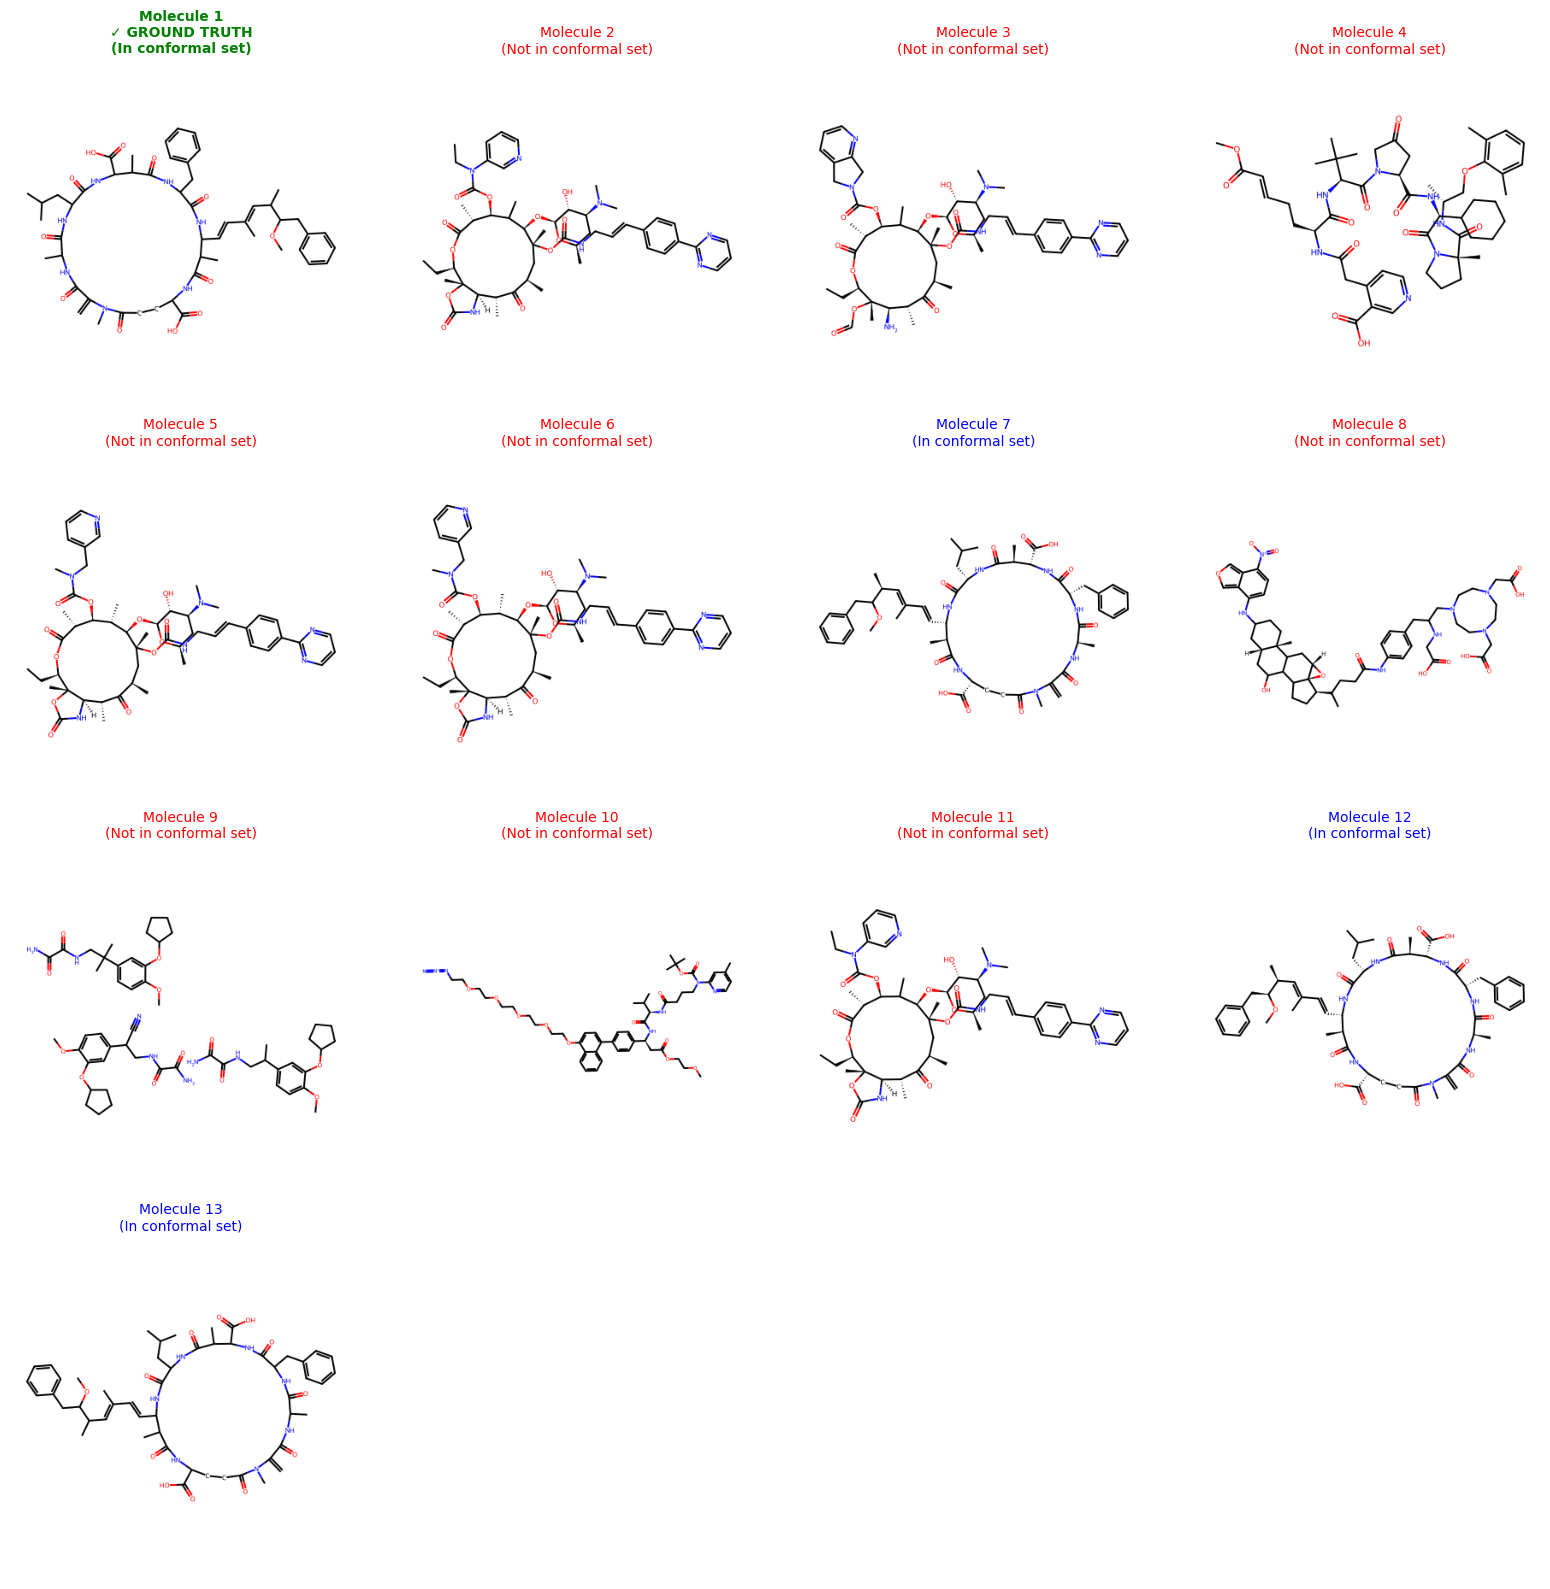


Summary:
  Green: Ground truth (in conformal set)
  Blue: In conformal set (but not ground truth)
  Red: Not in conformal set
  Total in conformal set: 4/13


In [61]:
# Visualize the complete candidate set for a specific example
target_sample_id = 'idx_58889'

# Find the example
target_example = None
for r in test_results:
    if r['sample_id'] == target_sample_id:
        target_example = r
        break

if target_example:
    print("="*80)
    print(f"COMPLETE CANDIDATE SET VISUALIZATION")
    print("="*80)
    print(f"\nSample ID: {target_example['sample_id']}")
    print(f"Original Candidate Set Size: {target_example['candidate_set_size']}")
    print(f"Conformal Set Size: {target_example['conformal_set_size']}")
    print(f"Size Reduction: {100*(1 - target_example['conformal_set_size']/target_example['candidate_set_size']):.1f}%")
    
    # Get all candidates from the original candidate set
    true_smiles = target_example['true_smiles']
    all_candidates = candidates_dict[true_smiles]
    conformal_set = target_example['conformal_set']
    
    print(f"\nTotal candidates to display: {len(all_candidates)}")
    
    # Create grid layout (4 columns)
    n_candidates = len(all_candidates)
    n_cols = 4
    n_rows = (n_candidates + n_cols - 1) // n_cols  # Ceiling division
    
    fig = plt.figure(figsize=(16, 4 * n_rows))
    
    from rdkit import Chem
    from rdkit.Chem import Draw
    
    for i, smiles in enumerate(all_candidates):
        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            img = Draw.MolToImage(mol, size=(400, 400))
            ax.imshow(img)
            ax.axis('off')
            
            # Determine status
            is_gt = smiles == true_smiles
            in_conformal = smiles in conformal_set
            
            if is_gt:
                title = f"Molecule {i+1}\n✓ GROUND TRUTH\n(In conformal set)"
                color = 'green'
                weight = 'bold'
            elif in_conformal:
                title = f"Molecule {i+1}\n(In conformal set)"
                color = 'blue'
                weight = 'normal'
            else:
                title = f"Molecule {i+1}\n(Not in conformal set)"
                color = 'red'
                weight = 'normal'
            
            ax.set_title(title, fontsize=10, fontweight=weight, color=color)
    
    plt.tight_layout()
    
    # Save as PDF
    pdf_filename = f"complete_candidate_set_{target_sample_id}.pdf"
    plt.savefig(pdf_filename, format='pdf', bbox_inches='tight', dpi=300)
    print(f"\n✓ Saved complete candidate set visualization to: {pdf_filename}")
    
    plt.show()
    
    # Print summary
    print(f"\nSummary:")
    print(f"  Green: Ground truth (in conformal set)")
    print(f"  Blue: In conformal set (but not ground truth)")
    print(f"  Red: Not in conformal set")
    print(f"  Total in conformal set: {len(conformal_set)}/{len(all_candidates)}")
    
else:
    print(f"Example with sample_id '{target_sample_id}' not found in test results")
